In [1]:
import pandas as pd

In [2]:
!pip install seaborn


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv('../data/Togo/solar-measurements_togo-dapaong_qc.csv', encoding='latin1', skiprows=[1])
print("summary statistics")
display(df.describe())

summary statistics


,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,GHIrsi,Comments
count,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,0.0
mean,230.555040,151.258469,116.444352,226.144375,219.568588,27.751788,55.013160,2.368093,3.229490,0.557740,161.741845,10.559568,975.915242,0.000535,0.001382,32.444403,33.543330,227.765822,NaN
std,322.532347,250.956962,156.520714,317.346938,307.932510,4.758023,28.778732,1.462668,1.882565,0.268923,91.877217,5.915490,2.153977,0.023116,0.026350,10.998334,12.769277,316.931191,NaN
min,-12.700000,0.000000,0.000000,0.000000,0.000000,14.900000,3.300000,0.000000,0.000000,0.000000,0.000000,0.000000,968.000000,0.000000,0.000000,13.100000,13.100000,0.000000,NaN
25%,-2.200000,0.000000,0.000000,0.000000,0.000000,24.200000,26.500000,1.400000,1.900000,0.400000,74.800000,6.900000,975.000000,0.000000,0.000000,23.900000,23.600000,0.000000,NaN
50%,2.100000,0.000000,2.500000,4.400000,4.300000,27.200000,59.300000,2.200000,2.900000,0.500000,199.100000,10.800000,976.000000,0.000000,0.000000,28.400000,28.400000,2.500000,NaN
75%,442.400000,246.400000,215.700000,422.525000,411.000000,31.100000,80.800000,3.200000,4.400000,0.700000,233.500000,14.100000,977.000000,0.000000,0.000000,40.600000,43.000000,431.500000,NaN
max,1424.000000,1004.500000,805.700000,1380.000000,1367.000000,41.400000,99.800000,16.100000,23.100000,4.700000,360.000000,86.900000,983.000000,1.000000,2.300000,70.400000,94.600000,1424.800000,NaN


In [7]:
print("\nMissing Values:")
display(df.isna().sum())


Missing Values:


Timestamp             0
GHI                   0
DNI                   0
DHI                   0
ModA                  0
ModB                  0
Tamb                  0
RH                    0
WS                    0
WSgust                0
WSstdev               0
WD                    0
WDstdev               0
BP                    0
Cleaning              0
Precipitation         0
TModA                 0
TModB                 0
GHIrsi                0
Comments         525600
dtype: int64

In [8]:
import numpy as np
from scipy import stats

In [9]:
df = df.drop(columns=['Comments'])

Checking for the negative values in GHI, DNI, DHI

In [10]:
radiation_cols=['GHI','DNI','DHI']
negative_cols = (df[radiation_cols]<0).sum()
print("Negative values in radiation columns:\n", negative_cols)

Negative values in radiation columns:
 GHI    257385
DNI         0
DHI         0
dtype: int64


In [11]:
cols_to_check = ['GHI','DNI','DHI', 'ModA','ModB','WS','WSgust']

In [12]:
z_scores= np.abs(stats.zscore(df[cols_to_check]))
outliers_mask=(z_scores>3).any(axis=1)
print(f"\nRows flagged as outliers: {outliers_mask.sum()}")


Rows flagged as outliers: 9251


In [13]:
for col in ['GHI','DNI','DHI']:
    df.loc[df[col]<0,col]=0

In [15]:
df_clean = df[~outliers_mask].copy()
print(f"Original rows: {len(df)}")
print(f"Cleaned rows:{len(df_clean)}")
print(f"Remaining negatives: {(df_clean[['GHI','DNI','DHI']]<0).sum().sum()}")

Original rows: 525600
Cleaned rows:516349
Remaining negatives: 0


In [16]:
df_clean['Timestamp'] = pd.to_datetime(df_clean['Timestamp'])

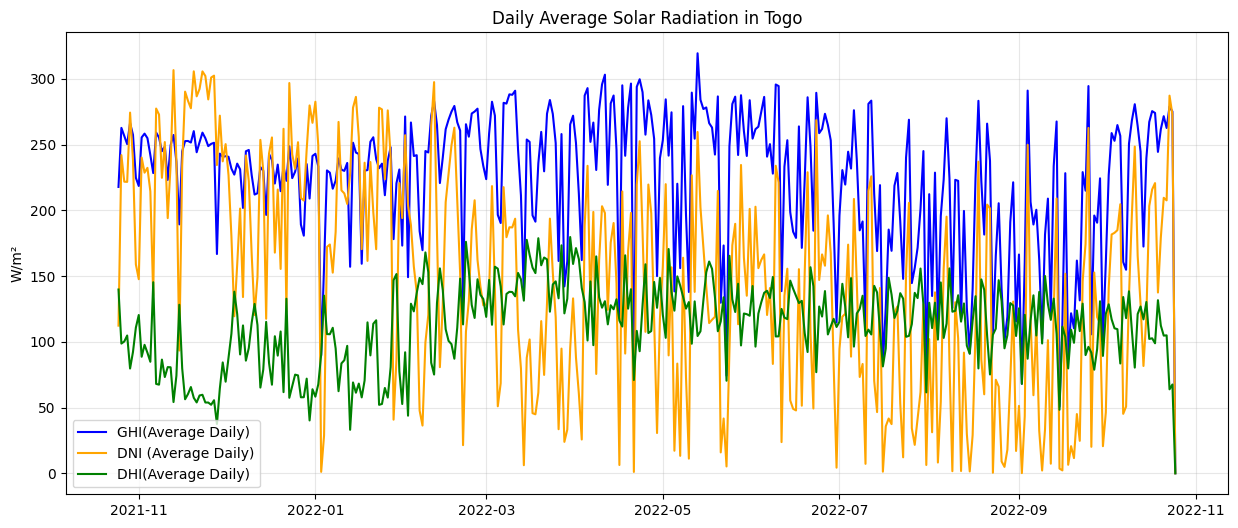

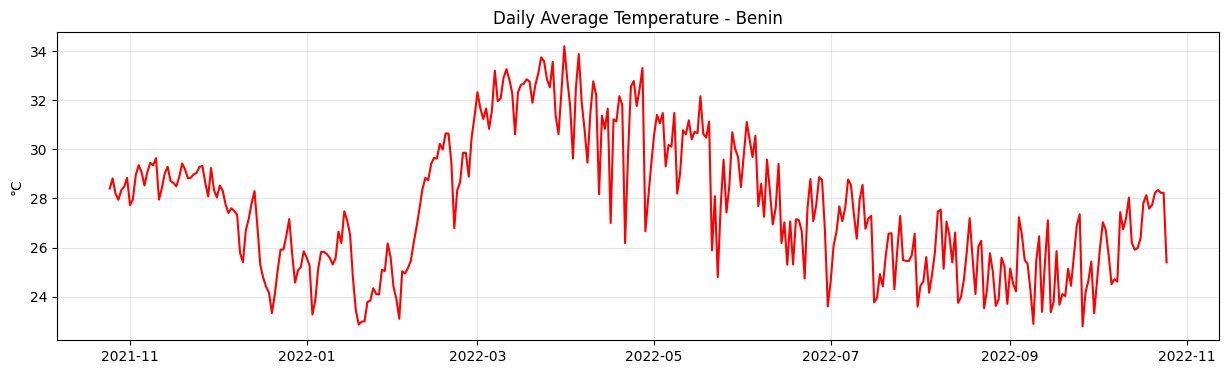

In [30]:
sample_data = df_clean.set_index('Timestamp').resample('D').mean()

plt.figure(figsize=(15,6))

plt.plot(sample_data.index, sample_data['GHI'], label='GHI(Average Daily)', color='blue')

plt.plot(sample_data.index, sample_data['DNI'], label='DNI (Average Daily)', color='orange')

plt.plot(sample_data.index, sample_data['DHI'], label='DHI(Average Daily)', color='green')

plt.title('Daily Average Solar Radiation in Togo')
plt.ylabel('W/m²')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Daily Average Temperature over time
plt.figure(figsize=(15, 4))
plt.plot(sample_data.index, sample_data['Tamb'], color='red')
plt.title('Daily Average Temperature - Benin')
plt.ylabel('°C')
plt.grid(True, alpha=0.3)
plt.show()

cleaning flag

In [22]:
cleaning_impact = df_clean.groupby('Cleaning')[['ModA','ModB']].mean()

Average sensor Readings (Cleaned vs uncleaned):


,ModA,ModB
Cleaning,,
0,219.217037,212.861920
1,528.864835,527.268498


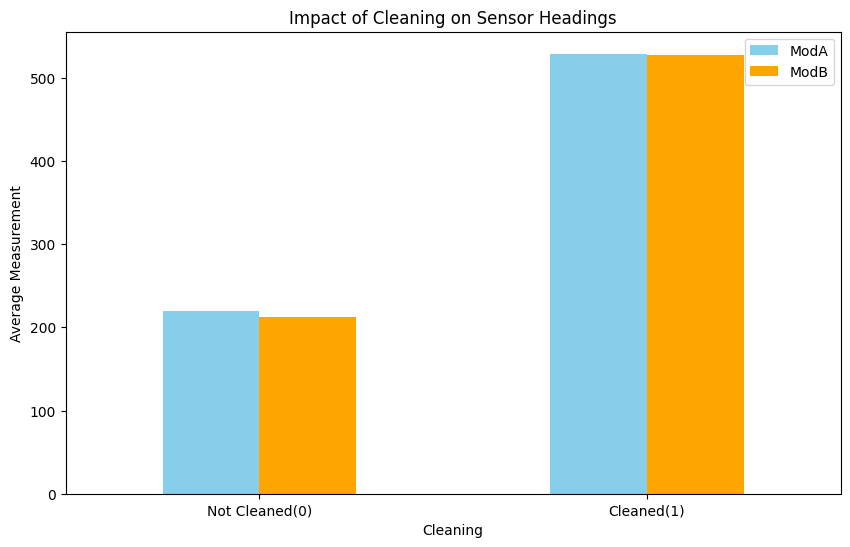

In [23]:
print("Average sensor Readings (Cleaned vs uncleaned):")
display(cleaning_impact)

#plot the impact
cleaning_impact.plot(kind='bar', figsize=(10,6),color=['skyblue','orange'])
plt.title('Impact of Cleaning on Sensor Headings')
plt.ylabel('Average Measurement')
plt.xticks([0,1],['Not Cleaned(0)', 'Cleaned(1)'], rotation=0)
plt.show()

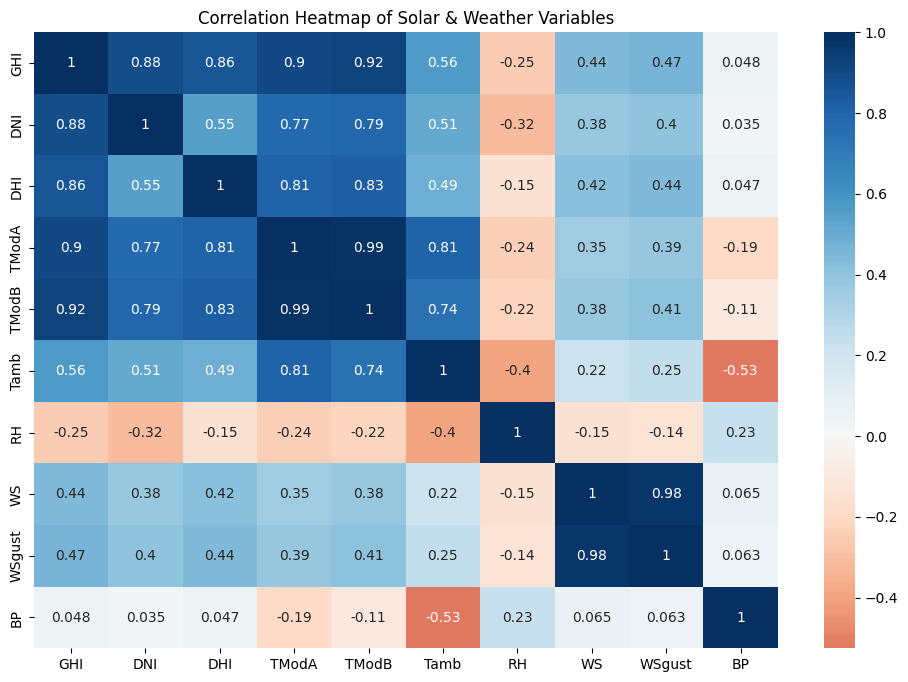

In [24]:
#selecting main columns for correlation
corr_cols = ['GHI', 'DNI', 'DHI', 'TModA', 'TModB', 'Tamb', 'RH', 'WS', 'WSgust', 'BP']
correlation_matrix = df_clean[corr_cols].corr()

# 2. Plot the Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu', center=0)
plt.title('Correlation Heatmap of Solar & Weather Variables')
plt.show()

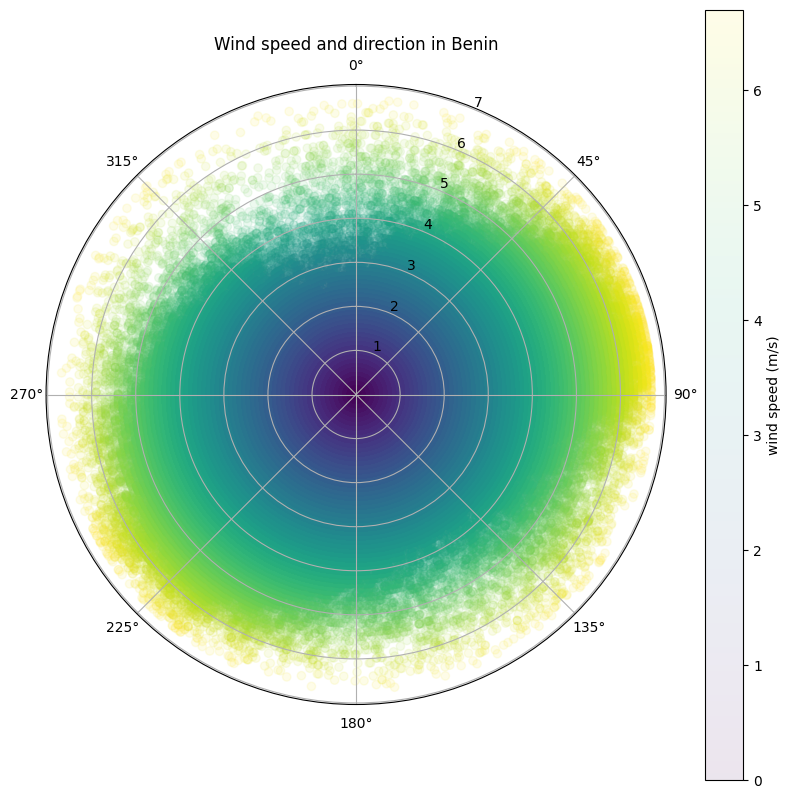

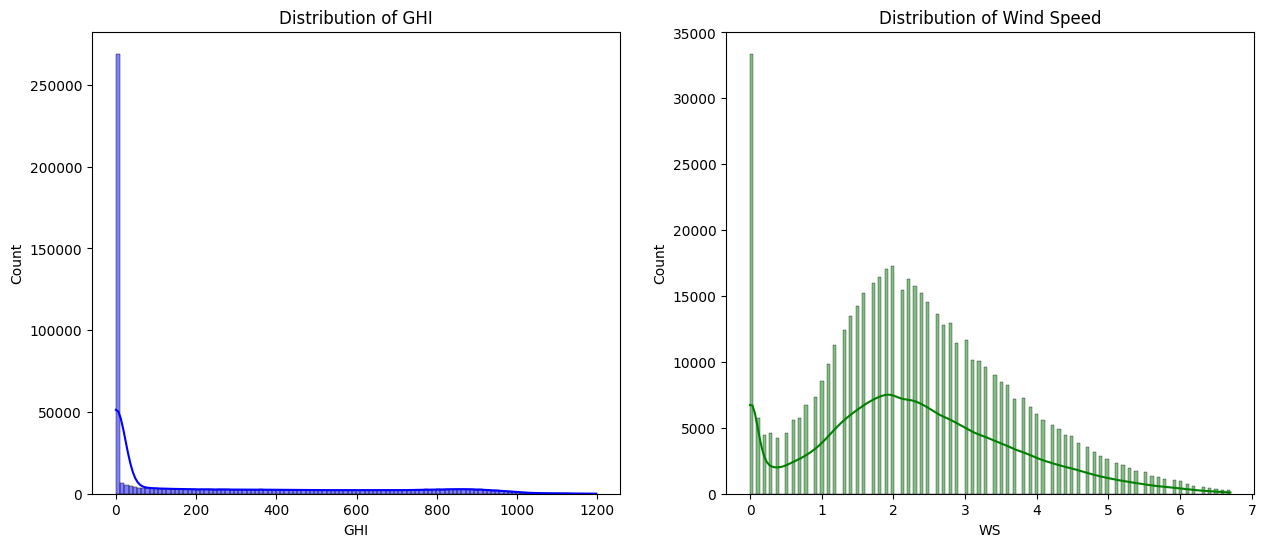

In [ ]:
plt.figure(figsize=(10,10))
ax=plt.subplot(111, polar=True)
ax.set_theta_direction(-1)
ax.set_theta_zero_location('N')

#plot wind direction and speed
plt.scatter(np.deg2rad(df_clean['WD']),
df_clean['WS'],alpha=0.1, c=df_clean['WS'],cmap='viridis')
plt.title('Wind speed and direction in Togo')
plt.colorbar(label='wind speed (m/s)')
plt.show()

#Distribution Analysis- histograms
# 2. Distribution Analysis - Histograms
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
sns.histplot(df_clean['GHI'], kde=True, color='blue')
plt.title('Distribution of GHI')
plt.subplot(1, 2, 2)
sns.histplot(df_clean['WS'], kde=True, color='green')
plt.title('Distribution of Wind Speed')
plt.show()

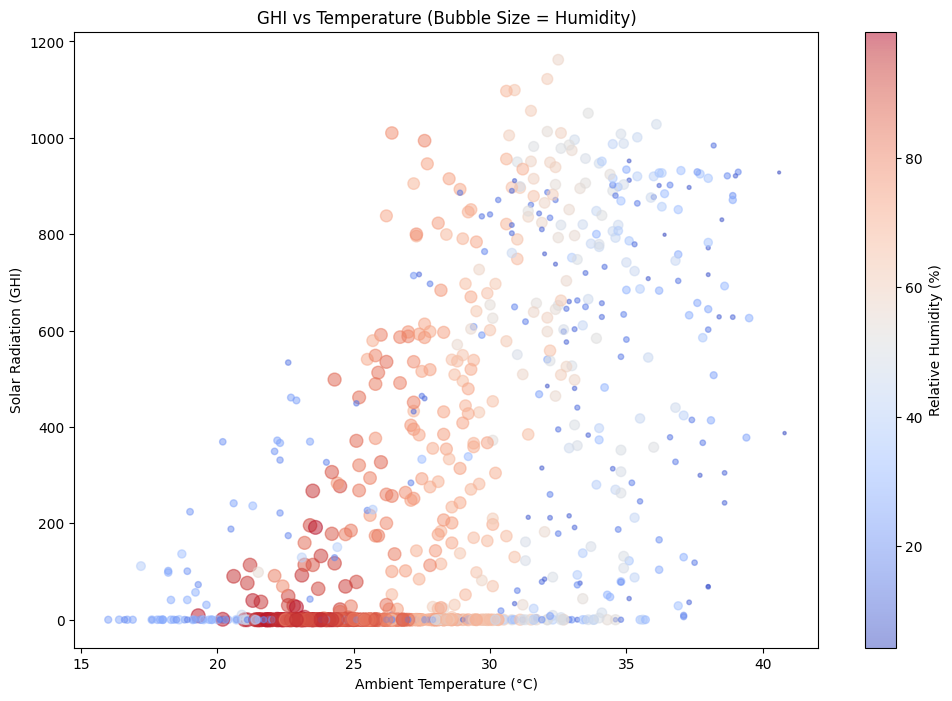

In [28]:
# Select a small random sample (e.g., 1000 rows) so the bubbles aren't too crowded
sample_bubble = df_clean.sample(1000)

plt.figure(figsize=(12, 8))
plt.scatter(sample_bubble['Tamb'], sample_bubble['GHI'], 
            s=sample_bubble['RH'], # Size of bubble = Humidity
            alpha=0.5, 
            c=sample_bubble['RH'], # Color can also = Humidity
            cmap='coolwarm')

plt.title('GHI vs Temperature (Bubble Size = Humidity)')
plt.xlabel('Ambient Temperature (°C)')
plt.ylabel('Solar Radiation (GHI)')
plt.colorbar(label='Relative Humidity (%)')
plt.show()

In [29]:
df_clean.to_csv('../data/benin_clean.csv', index=False)
print("Benin cleaned data saved!")

Benin cleaned data saved!
